# Support Vector Regression - Implimentation
- Problem Statement: To predict the salary of an individual given the level
- As the dataset size is small the entire dataset is used for training
- X = Level and y = Salary

In [1]:
import pandas as pd
df = pd.read_csv("../../../../datasets/Position_Salaries.csv")
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


# Seperating dependent and independent variables

In [2]:
X = df[["Level"]]
y = df[["Salary"]]

# Feature scaling
- Both X and the target variables are numerical values
- Both must be scaled
- Since we are using entire dataset we dont have to worry about applying scaling after the splitting
- 2 different scalars are defined, 1 for X and 1 for y because both will be in different ranges 

In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np


scalar_x = StandardScaler()
scalar_y =  StandardScaler()
X_scaled = scalar_x.fit_transform(X)
y_scaled = scalar_y.fit_transform(y)

In [4]:
y_scaled

array([[-0.72004253],
       [-0.70243757],
       [-0.66722767],
       [-0.59680786],
       [-0.49117815],
       [-0.35033854],
       [-0.17428902],
       [ 0.17781001],
       [ 0.88200808],
       [ 2.64250325]])

# Training the model

In [5]:
from sklearn.svm import SVR

model = SVR()
model.fit(X_scaled, y_scaled)

/Users/ritumalage/Documents/my_github/Notes/.venv_aiml/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


### Predict the salary for the level = 6.5

In [6]:
y_pred = model.predict(scalar_x.transform([[6.5]]))
y_pred

/Users/ritumalage/Documents/my_github/Notes/.venv_aiml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-0.27861589])

- Since y was also scaled the output that we get from the predict method is also scaled 
- To get the original output we will need to inverse the scale by using `inverse_transform()`

In [7]:
scalar_y.inverse_transform([y_pred])

array([[170370.0204065]])

# Visualize the results

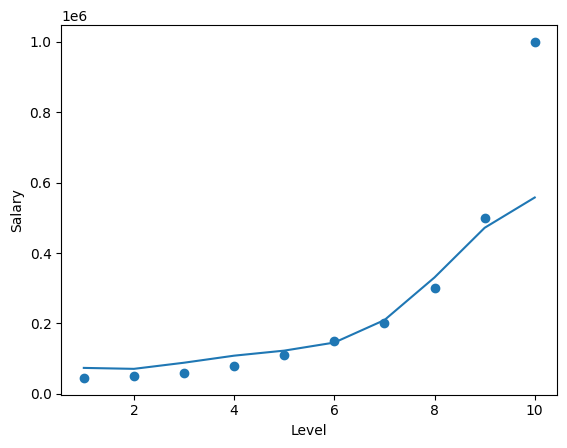

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
# Predict the values -> results will be scaled thus undo/ reverse the scale by using inverse transform
y_pred = model.predict(scalar_x.transform(X))
y_pred = scalar_y.inverse_transform([y_pred])

plt.plot(X, y_pred.reshape(-1,1))
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()